<a href="https://colab.research.google.com/github/YannnnnaY/Course-Projects/blob/main/Mobile_Games_AB_Testing_with_Cookie_Cats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
cookie_cats_path = kagglehub.dataset_download('mursideyarkin/mobile-games-ab-testing-cookie-cats')

print('Data source import complete.')


100%|██████████| 487k/487k [00:00<00:00, 35.7MB/s]

Extracting files...
Data source import complete.


## <font color="#00bfff">1.Cookie Cats and Project Goal</font>
<p><a href="https://www.facebook.com/cookiecatsgame">Cookie Cats</a> is a hugely popular mobile puzzle game developed by <a href="http://tactile.dk">Tactile Entertainment</a>. It's a classic "connect three"-style puzzle game where the player must connect tiles of the same color to clear the board and win the level.
    <p><img src="https://i.ytimg.com/vi/LkvnfULq8yQ/maxresdefault.jpg" style="max-width:350px"></p>
<p>As players progress through the levels of the game, they will occasionally encounter gates that force them to wait a non-trivial amount of time or make an in-app purchase to progress. In addition to driving in-app purchases, these gates serve the important purpose of giving players an enforced break from playing the game, hopefully resulting in that the player's enjoyment of the game being increased and prolonged.</p>
<p><img src="https://assets.datacamp.com/production/project_184/img/cc_gates.png" style="max-width:350px"></p>
<p>But where should the gates be placed? Initially the first gate was placed at level 30, but in this notebook we're going to analyze an AB-test where we moved the first gate in Cookie Cats from level 30 to level 40. In particular, we will look at the impact on player retention. But before we get to that, a key step before undertaking any analysis is understanding the data.</p>


## <font color="#00bfff">2. Dataset and Variables</font>
The data we have is from 90,189 players that installed the game while the AB-test was running. The variables are:

<li><code>userid</code> - a unique number that identifies each player.</li>
<li><code>version</code> - whether the player was put in the control group (<code>gate_30</code> - a gate at level 30) or the group with the moved gate (<code>gate_40</code> - a gate at level 40).</li>
<li><code>sum_gamerounds</code> - the number of game rounds played by the player during the first 14 days after install.</li>
<li><code>retention_1</code> - did the player come back and play <strong>1 day</strong> after installing?</li>
<li><code>retention_7</code> - did the player come back and play <strong>7 days</strong> after installing?</li>

<p>When a player installed the game, he or she was randomly assigned to either <code>gate_30</code> or <code>gate_40</code>.

 So let's load it in and take a look!

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Construct the full path to the CSV file
file_path = os.path.join(cookie_cats_path, 'cookie_cats.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(df.head())

   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True


## <font color="#00bfff">3. Descriptive Statistics</font>


<p><img src="https://assets.datacamp.com/production/project_184/img/mr_waffles_smiling.png" style="width:150px; float:right;margin: -15px 20px 1px 15px;"> </p>

Let's deep dive into dataset and try to observe the differences between A/B group in terms of given variables.

In [4]:
# number of unique player
total_players = df["userid"].nunique()

# number of players in each group
version_counts = df.groupby("version")["userid"].nunique()
gate_30_count = version_counts['gate_30']
gate_40_count = version_counts['gate_40']

print('total unique players: ', total_players)
print('number of players in each group: ', version_counts)

total unique players:  90189
number of players in each group:  version
gate_30    44700
gate_40    45489
Name: userid, dtype: int64


In [5]:
from scipy.stats import chisquare

# Expected count for each group under the null hypothesis of equal distribution
expected_count = total_players / 2

# Perform the chi-square test for homogeneity
# Observed frequencies
observed = [gate_30_count, gate_40_count]
# Expected frequencies (assuming perfectly equal distribution)
expected = [expected_count, expected_count]

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Observed counts: Gate 30 = {gate_30_count}, Gate 40 = {gate_40_count}")
print(f"Expected count per group (if perfectly equal): {expected_count:.2f}")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05 # Significance level

if p_value < alpha:
    print("\nConclusion: The difference in sample sizes between the two A/B groups is statistically significant.")
else:
    print("\nConclusion: The difference in sample sizes between the two A/B groups is not statistically significant. This suggests that the randomization was effective in distributing players evenly.")

Observed counts: Gate 30 = 44700, Gate 40 = 45489
Expected count per group (if perfectly equal): 45094.50
Chi-square statistic: 6.9024
P-value: 0.0086

Conclusion: The difference in sample sizes between the two A/B groups is statistically significant.


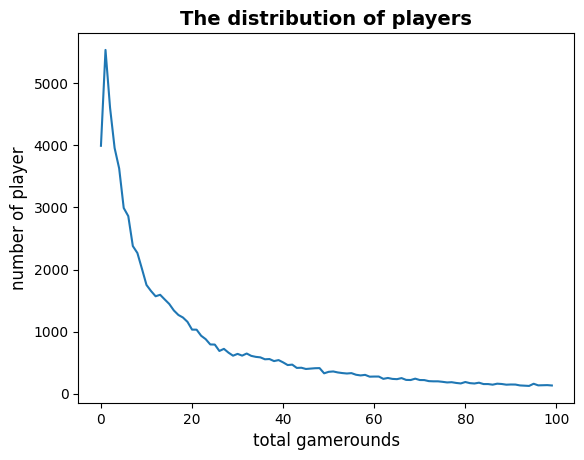

In [6]:
# The distribution of game rounds

# Counting the number of players for each number of gamerounds
plot_df = df.groupby("sum_gamerounds")["userid"].count()

# Plotting the distribution of players that played 0 to 100 game rounds
ax = plot_df.head(100).plot()
plt.title("The distribution of players", fontweight="bold", size=14)
plt.xlabel("total gamerounds", size=12)
plt.ylabel("number of player", size=12)
plt.show()

In [7]:
df_retention = df[["retention_1","retention_7"]].mean()*100
print(f"1-day retention ratio: {round(df_retention[0],2)}% \n7-days retention ratio: {round(df_retention[1],2)}% ")

# Calculate the ratio of user_id who didn't play at all
no_play_count = df[df["sum_gamerounds"]== 0]["userid"].nunique()
no_play_ratio = (no_play_count / total_players) * 100
print(f"Ratio of users who didn't play any game rounds: {round(no_play_ratio, 2)}%")

1-day retention ratio: 44.52% 
7-days retention ratio: 18.61% 
Ratio of users who didn't play any game rounds: 4.43%


/tmp/ipykernel_5792/3868294590.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"1-day retention ratio: {round(df_retention[0],2)}% \n7-days retention ratio: {round(df_retention[1],2)}% ")


95% of the players played after installation.    
45% of the players come back 1 day after installing the game.    
19% of the players come back 7 day after installing the game.

In [8]:
# Calculating 1-day and 7-days retention for each A/B group
df_retention_ab = df.groupby("version").agg(
    {
        "userid":"count",
        "retention_1":"mean",
        "retention_7":"mean",
        "sum_gamerounds":"sum"
        }
    )
df_retention_ab

,userid,retention_1,retention_7,sum_gamerounds
version,,,,
gate_30,44700,0.448188,0.190201,2344795
gate_40,45489,0.442283,0.182000,2333530


* There was a slight decrease in both retention when the gate was moved to level 40 from level 30.

* It's a minor change, but even small changes in retention can have a large impact.


## <font color="#00bfff"> 4. A/B Testing: Bootstrapping </font>

**Definiton of Method**

We will use **bootstrapping.** to see how certain we should be that a gate at level 40 will make the retention worse in the future.  

- The basic idea of bootstrapping is that inference about a population from sample data (sample → population) can be modelled by resampling the sample data and performing inference about a sample from resampled data (resampled → sample).

- As the population is unknown, the true error in a sample statistic against its population value is unknown. In bootstrap-resamples, the 'population' is in fact the sample, and this is known; hence the quality of inference of the 'true' sample from resampled data (resampled → sample) is measurable.
 https://en.wikipedia.org/wiki/Bootstrapping_(statistics)


- Why Bootstrapping?
    - It doesn't assume that the data comes from a specific distribution (like a normal distribution). This is very useful when dealing with metrics like retention, which can be skewed or have unusual shapes.   
    - It helps us create an empirical sampling distribution for a statistic (like the difference in retention rates between two groups). By repeatedly resampling the observed data with replacement, we simulate many different possible datasets that could have been drawn from the true underlying population.   
    - From these many resamples, we can construct confidence intervals for our metrics and calculate the probability that one group is truly better than the other



**Testing Steps:**
1. Creating 500 samples of dataset **(bootstraping)**
2. Calculating 1-day & 7-days retentions for A/B groups
3. Plotting the bootstrap distributions
4. Calculating retention rate difference between the two A/B groups
5. Calculating the probability that 1-day & 7-days retentions are greater when the gate is at level 30
6. Evaluating results and making recommendation

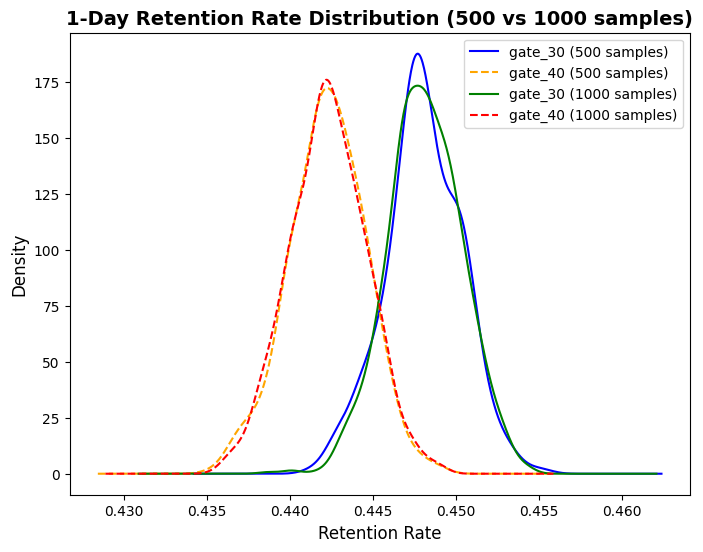

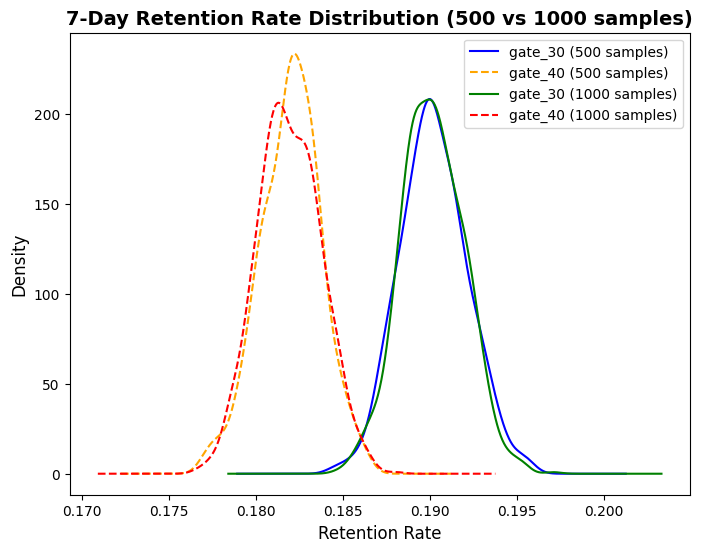

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42) # Set a random seed for reproducibility

def run_bootstrap_simulation(num_iterations, dataframe):
    boot_1d_results = []
    boot_7d_results = []
    for i in range(num_iterations):
        # Sample the dataframe once per iteration to ensure consistency for both retention metrics
        boot_df_sample = dataframe.sample(frac=1, replace=True)
        boot_mean_1 = boot_df_sample.groupby('version')['retention_1'].mean()
        boot_mean_7 = boot_df_sample.groupby('version')['retention_7'].mean()
        boot_1d_results.append(boot_mean_1)
        boot_7d_results.append(boot_mean_7)
    return pd.DataFrame(boot_1d_results), pd.DataFrame(boot_7d_results)

# Run simulations for 500 iterations
boot_1d_500, boot_7d_500 = run_bootstrap_simulation(500, df)

# Run simulations for 1000 iterations
boot_1d_1000, boot_7d_1000 = run_bootstrap_simulation(1000, df)


# --- Plotting for 1-day retention comparison ---
fig_1d, ax_1d = plt.subplots(1, 1, figsize=(8, 6))
boot_1d_500['gate_30'].plot.kde(ax=ax_1d, label='gate_30 (500 samples)', linestyle='-', color='blue')
boot_1d_500['gate_40'].plot.kde(ax=ax_1d, label='gate_40 (500 samples)', linestyle='--', color='orange')
boot_1d_1000['gate_30'].plot.kde(ax=ax_1d, label='gate_30 (1000 samples)', linestyle='-', color='green')
boot_1d_1000['gate_40'].plot.kde(ax=ax_1d, label='gate_40 (1000 samples)', linestyle='--', color='red')
ax_1d.set_xlabel("Retention Rate", size=12)
ax_1d.set_ylabel("Density", size=12)
ax_1d.set_title("1-Day Retention Rate Distribution (500 vs 1000 samples)", fontweight="bold", size=14)
ax_1d.legend()
plt.show()

# --- Plotting for 7-day retention comparison ---
fig_7d, ax_7d = plt.subplots(1, 1, figsize=(8, 6))
boot_7d_500['gate_30'].plot.kde(ax=ax_7d, label='gate_30 (500 samples)', linestyle='-', color='blue')
boot_7d_500['gate_40'].plot.kde(ax=ax_7d, label='gate_40 (500 samples)', linestyle='--', color='orange')
boot_7d_1000['gate_30'].plot.kde(ax=ax_7d, label='gate_30 (1000 samples)', linestyle='-', color='green')
boot_7d_1000['gate_40'].plot.kde(ax=ax_7d, label='gate_40 (1000 samples)', linestyle='--', color='red')
ax_7d.set_xlabel("Retention Rate", size=12)
ax_7d.set_ylabel("Density", size=12)
ax_7d.set_title("7-Day Retention Rate Distribution (500 vs 1000 samples)", fontweight="bold", size=14)
ax_7d.legend()
plt.show()

<p>These two distributions above represent the bootstrap uncertainty over what the underlying 1-day & 7-days retention could be for the two A/B groups. Just eyeballing this plot, we can see that there seems to be some evidence of a difference, albeit small. Let's zoom in on the differences.</p>

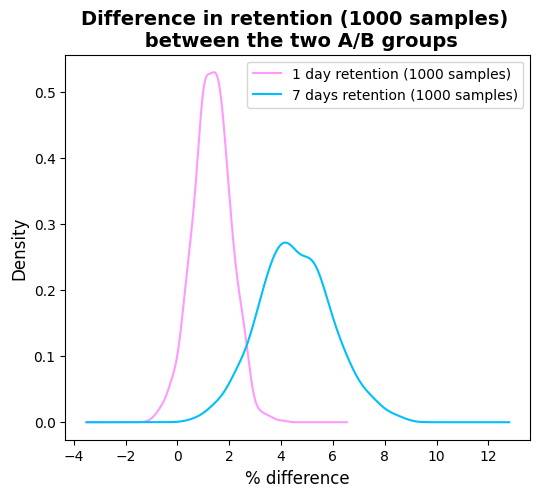

In [10]:
# Adding a column with the % difference between the two A/B groups, using 1000 iterations
boot_1d_1000['diff'] = ((boot_1d_1000['gate_30'] - boot_1d_1000['gate_40']) / boot_1d_1000['gate_40'] * 100)
boot_7d_1000['diff'] = ((boot_7d_1000['gate_30'] - boot_7d_1000['gate_40']) / boot_7d_1000['gate_40'] * 100)

# Ploting the bootstrap % difference
fig, (ax1) = plt.subplots(1, 1,figsize=(6,5))

boot_1d_1000['diff'].plot.kde(ax=ax1, c="#ff99ff", label = "1 day retention (1000 samples)")
boot_7d_1000['diff'].plot.kde(ax=ax1, c= "#00bfff", label = "7 days retention (1000 samples)")
ax1.set_xlabel("% difference",size=12)
ax1.set_ylabel("Density",size=12)
ax1.set_title("Difference in retention (1000 samples) \n between the two A/B groups", fontweight="bold", size=14)
plt.legend()
plt.show()


<p>From these chart, we can see that the most likely % difference is around 1% - 2% for 1-day retention. For 7-days retention the most likely % difference is around 3% - 6%.

In [12]:
# check the probability that 1-day retention is greater when the gate is at level 30
prob_1 = (boot_1d_1000['diff']>0).sum()/len(boot_1d_1000['diff'])

# check the probability that 7-days retention is greater when the gate is at level 30
prob_7 = (boot_7d_1000['diff']>0).sum()/len(boot_7d_1000['diff'])

print(f"The probability that 1-day retention is greater when the gate is at level 30: {round(prob_1,2)*100}% \
      \nThe probability that 7-days retention is greater when the gate is at level 30: {(prob_7)*100}% ")

The probability that 1-day retention is greater when the gate is at level 30: 96.0%       
The probability that 7-days retention is greater when the gate is at level 30: 100.0% 


## <font color="00bfff">5. The conclusion</font>

The bootstrap result tells us that there is strong evidence **99.8% probability** that 7-day retention is higher when the gate is at level 30 than when it is at level 40.

The conclusion is: If we want to keep retention high — both 1-day and 7-day retention — we should <strong>not</strong> move the gate from level 30 to level 40. There are, of course, other metrics we could look at, like the number of game rounds played or how much in-game purchases are made by the two AB-groups. But retention <em>is</em> one of the most important metrics.
